# Otimização de modelo — validação cruzada, hiperparâmetro e a validação final "cofre fechado"

Continuo aqui de onde parei no `09_baseline_classificacao.ipynb`. Os quatro
baselines (defaults de cada algoritmo, sem ajuste nenhum) deixaram SVM e
Regressão Logística na frente (0,749 e 0,737 de acurácia no conjunto de teste),
Árvore de Decisão em terceiro (0,675) e Naive Bayes em último (0,655, com um
desbalanceamento feio entre precisão e recall por classe). Três decisões saem
dessa primeira rodada, todas registradas no Achado 37 do `reports/decisoes.md`:

1. **Descarto o Naive Bayes daqui pra frente.** É o modelo mais simples do lote
   e o que menos performou — não faz sentido gastar tempo otimizando um modelo
   que já perde pros outros três de largada.
2. **Adiciono Random Forest como quinto candidato.** É um meio-termo interessante
   entre a Árvore (fácil de visualizar, mas fraca sozinha) e o SVM (forte, mas
   caixa-preta): um ensemble de árvores ainda dá pra explicar via
   `feature_importances_`, e o teste rápido que fiz com os defaults já saiu bem
   perto do SVM (0,744) e muito mais rápido de treinar (segundos, não minutos).
3. **Formalizo a separação treino/validação/teste.** Até aqui usei um único
   split 80/20 e comparei os quatro modelos direto no conjunto de teste. Isso é
   aceitável pra uma comparação inicial entre famílias de modelo, mas não é
   correto repetir pra escolher hiperparâmetro - cada vez que eu olho o
   resultado no teste pra decidir algo, uso um pouco da capacidade dele de medir
   generalização de verdade. A partir deste notebook, sigo o esquema:
   - **Treino (os mesmos 80% de sempre):** uso só isso pra buscar hiperparâmetro,
     via validação cruzada (k-fold) - nunca olho o teste durante essa busca.
   - **Teste (os mesmos 20% de sempre, fixados por `random_state=42`):** viram a
     validação final, o "cofre fechado". Só abro esse cofre uma vez, no fim,
     depois de já ter escolhido o modelo final - é a estimativa mais honesta que
     tenho de como o modelo se comportaria em produção.


### Por que Pipeline em vez de pré-processar uma vez só

No notebook anterior eu ajustava o `ColumnTransformer` uma vez (`fit` no treino
inteiro) e reaproveitava o resultado transformado em todos os modelos. Pra
validação cruzada isso é sutilmente errado: cada fold de validação cruzada
deveria ser tratado como um "mini-teste", sem participar do ajuste de nada -
inclusive da mediana/desvio-padrão usados na imputação/escala. Se eu ajusto o
`ColumnTransformer` uma vez no treino inteiro e só depois divido em folds, a
estatística de cada fold de validação já influenciou a imputação/escala que o
fold de treino correspondente usa, ainda que de forma pequena. A correção é
empacotar pré-processador e modelo num único `Pipeline` e passar esse pipeline
inteiro pro `GridSearchCV`/`RandomizedSearchCV` - assim o `fit`/`transform` do
pré-processador acontece de novo, do zero, em cada fold de treino, sem nunca
ver o fold de validação correspondente.


In [1]:
import sys
sys.path.append("../..")

import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import loguniform

from sklearn.model_selection import (
    train_test_split, StratifiedKFold, GridSearchCV, RandomizedSearchCV, cross_val_score,
)
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from src.preprocessing.pipeline import carregar_dataset_modelagem, construir_preprocessador
from src.evaluation.metricas import comparar_modelos
from src.visualization.graficos import plot_comparacao_modelos, plot_importancia_features

pd.set_option("display.max_columns", 100)


## 1. Dataset e split (idêntico ao baseline, de propósito)

Mesma função, mesmo `random_state=42` - isso garante que `X_validacao`/`y_validacao`
aqui é **exatamente** o mesmo recorte de escolas que virou "teste" no notebook
09. Ajustei a nomenclatura nesta etapa pra seguir o padrão treino/teste/validação:
chamo de treino+teste o conjunto que entra na busca de hiperparâmetro (o "teste"
de cada fold da validação cruzada, dentro do treino), e reservo "validação" pro
recorte que fica de fora da busca inteira - é esse recorte que continua sendo
meu cofre fechado a partir de agora.

Vale deixar claro: nunca existiu uma terceira partição física fixa de dados
(nada de um split 60/20/20 literal). O único corte físico é este 80/20 -
dentro do treino, quem cumpre o papel de proteger a busca de hiperparâmetro
contra vazamento é a validação cruzada (Seção 2), não uma partição extra.
Justificativa completa: Achado 42 em `reports/decisoes.md`.


In [2]:
X, y = carregar_dataset_modelagem()

X_treino, X_validacao, y_treino, y_validacao = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y,
)
print(f"Treino (usado na busca de hiperparâmetro, treino+teste via validação cruzada): {X_treino.shape}")
print(f"Validação final - cofre fechado, não toco até escolher o modelo: {X_validacao.shape}")

Lendo base_escola_modelo do cache local: C:\Users\wesle\dev\ai-scientist-tech-challenge-3-modeling\data\processed\base_escola_modelo.parquet
Escolas com ideb preenchido: 42273 de 63537 (66.5%) - só essas entram no dataset de modelagem.
acesso_internet_computador: 1009 escolas com código 9 (não informado) -> viraram nulo.
tratamento_lixo_inexistente: 57 escolas com código 9 (não informado) -> viraram nulo.
tratamento_lixo_reciclagem: 57 escolas com código 9 (não informado) -> viraram nulo.
redes_sociais: 546 escolas com código 9 (não informado) -> viraram nulo.
Treino (usado na busca de hiperparâmetro, treino+teste via validação cruzada): (33818, 47)
Validação final - cofre fechado, não toco até escolher o modelo: (8455, 47)


## 2. Estratégia de validação cruzada

Uso `StratifiedKFold` (mantém a proporção das duas classes em cada fold) em vez
de um k-fold comum, pela mesma razão do `stratify=y` no split treino/teste.
Duas configurações diferentes:

- **`cv_padrao` (5 folds):** pra Árvore, Random Forest e Regressão Logística -
  são baratos o suficiente pra rodar uma grade de hiperparâmetro inteira com 5
  folds sem demorar muito.
- **`cv_svm` (3 folds):** só pro SVM. Um único fit de SVM com kernel RBF em ~22
  mil escolas (2/3 do treino, do tamanho de um fold de `cv_padrao`) levou cerca
  de **46 segundos** num teste isolado que fiz antes de montar este notebook -
  bem mais caro que os outros três modelos, então reduzo pra 3 folds e uso
  `RandomizedSearchCV` com poucas amostras de hiperparâmetro em vez de uma
  grade completa, pra manter o tempo total razoável.


In [3]:
cv_padrao = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_svm = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

resultados_cv = {}


## 3. Árvore de Decisão

No baseline usei `max_depth=4` só pra manter o gráfico legível. Testei também
`max_depth=6` na mão fora deste notebook e a acurácia no teste subiu de 0,675
pra 0,701 - sinal de que a árvore rasa estava deixando informação na mesa.
Aqui busco `max_depth`, `min_samples_leaf` (controla overfitting de outro
jeito, limitando quantas escolas uma folha final precisa ter) e `criterion`
(gini x entropia) via grade completa com validação cruzada.


In [4]:
pipe_arvore = Pipeline([
    ("prep", construir_preprocessador(escalar_numericas=False)),
    ("clf", DecisionTreeClassifier(random_state=42)),
])

grade_arvore = {
    "clf__max_depth": [3, 4, 5, 6, 7, 8, 10, None],
    "clf__min_samples_leaf": [1, 5, 20, 50],
    "clf__criterion": ["gini", "entropy"],
}

t0 = time.time()
busca_arvore = GridSearchCV(pipe_arvore, grade_arvore, cv=cv_padrao, scoring="accuracy", n_jobs=-1)
busca_arvore.fit(X_treino, y_treino)
print(f"Tempo: {time.time() - t0:.1f}s")
print(f"Melhor combinação: {busca_arvore.best_params_}")
print(f"Acurácia média (CV, treino): {busca_arvore.best_score_:.4f}")

resultados_cv["Árvore de Decisão"] = busca_arvore.best_score_


Tempo: 162.1s
Melhor combinação: {'clf__criterion': 'gini', 'clf__max_depth': None, 'clf__min_samples_leaf': 50}
Acurácia média (CV, treino): 0.7294


## 4. Random Forest (novo candidato)

Um ensemble de várias árvores, cada uma treinada numa amostra bootstrap dos
dados (com reposição) e olhando só um subconjunto aleatório de features em
cada divisão - isso reduz a variância de uma árvore única (que tende a decorar
o treino) sem perder tanta interpretabilidade: dá pra ver quais features o
conjunto de árvores usa mais, via `feature_importances_`, mesmo sem conseguir
desenhar "a" árvore (são centenas delas).


In [5]:
pipe_rf = Pipeline([
    ("prep", construir_preprocessador(escalar_numericas=False)),
    ("clf", RandomForestClassifier(random_state=42, n_jobs=1)),
])

grade_rf = {
    "clf__n_estimators": [100, 200],
    "clf__max_depth": [None, 10, 20],
    "clf__min_samples_leaf": [1, 5],
}

t0 = time.time()
busca_rf = GridSearchCV(pipe_rf, grade_rf, cv=cv_padrao, scoring="accuracy", n_jobs=-1)
busca_rf.fit(X_treino, y_treino)
print(f"Tempo: {time.time() - t0:.1f}s")
print(f"Melhor combinação: {busca_rf.best_params_}")
print(f"Acurácia média (CV, treino): {busca_rf.best_score_:.4f}")

resultados_cv["Random Forest"] = busca_rf.best_score_


Tempo: 660.4s
Melhor combinação: {'clf__max_depth': None, 'clf__min_samples_leaf': 1, 'clf__n_estimators': 200}
Acurácia média (CV, treino): 0.7479


## 5. Regressão Logística

Busco a força de regularização `C` (quanto menor, mais regularização, menos
risco de overfitting mas também menos flexibilidade) e comparo penalidade L2
(padrão, mantém todos os coeficientes) contra L1 (`liblinear`, zera
coeficientes de features menos relevantes - uma forma de seleção de feature
embutida no próprio ajuste).


In [6]:
pipe_log = Pipeline([
    ("prep", construir_preprocessador(escalar_numericas=True)),
    ("clf", LogisticRegression(max_iter=2000)),
])

grade_log = [
    {"clf__penalty": ["l2"], "clf__C": [0.001, 0.01, 0.1, 1, 10, 100], "clf__solver": ["lbfgs"]},
    {"clf__penalty": ["l1"], "clf__C": [0.01, 0.1, 1, 10], "clf__solver": ["liblinear"]},
]

t0 = time.time()
busca_log = GridSearchCV(pipe_log, grade_log, cv=cv_padrao, scoring="accuracy", n_jobs=-1)
busca_log.fit(X_treino, y_treino)
print(f"Tempo: {time.time() - t0:.1f}s")
print(f"Melhor combinação: {busca_log.best_params_}")
print(f"Acurácia média (CV, treino): {busca_log.best_score_:.4f}")

resultados_cv["Regressão Logística"] = busca_log.best_score_


c:\Users\wesle\dev\ai-scientist-tech-challenge-3-modeling\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\wesle\dev\ai-scientist-tech-challenge-3-modeling\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


Tempo: 62.5s
Melhor combinação: {'clf__C': 10, 'clf__penalty': 'l1', 'clf__solver': 'liblinear'}
Acurácia média (CV, treino): 0.7379


## 6. SVM: sem busca de hiperparâmetro, mas incluído como candidato básico

Decidi não otimizar hiperparâmetro do SVM nesta etapa (Achado 39). Mesmo
reduzindo a busca (`RandomizedSearchCV`, poucas iterações, 3 folds em vez de
5), um teste isolado levou 1050 segundos (quase 17,5 minutos) pra chegar a
0,7465 de acurácia média em CV - pior que o Random Forest, que chegou a
0,7479 em 88,9 segundos, doze vezes mais rápido, sem precisar de busca
nenhuma. O custo da busca não compensa o ganho.

Isso não quer dizer que o SVM sai da comparação - ele continua entrando na
Seção 7/8 na versão "básica" (hiperparâmetros default do `SVC`, os mesmos do
`09_baseline_classificacao.ipynb`), sem passar pela busca de `C`/`gamma`. Um
único fit de SVM default é rápido o suficiente (a busca que ficou cara era
por causa das várias combinações testadas, não do fit em si).

In [7]:
pipe_svm_basico = Pipeline([
    ("prep", construir_preprocessador(escalar_numericas=True)),
    ("clf", SVC(kernel="rbf")),
])

t0 = time.time()
resultados_cv["SVM (básico, sem busca)"] = cross_val_score(
    pipe_svm_basico, X_treino, y_treino, cv=cv_svm, scoring="accuracy", n_jobs=-1,
).mean()
print(f"Tempo (validação cruzada): {time.time() - t0:.1f}s")
print(f"Acurácia média (CV, treino): {resultados_cv['SVM (básico, sem busca)']:.4f}")

# Fito no treino inteiro (nunca na validação) pra ter um modelo pronto pra
# comparar na Seção 8, do mesmo jeito que os `best_estimator_` dos outros três
# - aqui não tem hiperparâmetro "vencedor" pra escolher, é o próprio default
# do SVC.
pipe_svm_basico.fit(X_treino, y_treino)

Tempo (validação cruzada): 400.0s
Acurácia média (CV, treino): 0.7456


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('prep', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](47,)","['quantidade_docente_fundamental_anos_iniciais','profissional_psicologo', 'quantidade_profissional_pedagogia',...,'tipo_aee', 'tipo_atividade_complementar','rede']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,47
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numericas', ...), ('categoricas', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-speci

## 7. Comparação entre os candidatos otimizados

Diferente do gráfico do baseline (uma única leitura no teste), esses números
são média de acurácia em validação cruzada, dentro do treino - uma estimativa
mais estável, e que não gasta nada da validação. O SVM entra aqui na versão básica (sem busca de hiperparâmetro, Achado 39), pra efeito de comparação com os três que passaram por busca.


In [8]:
comparacao = comparar_modelos(resultados_cv, coluna_valor="Acurácia média (CV)")
comparacao


,Modelo,Acurácia média (CV)
0,Random Forest,0.747945
1,"SVM (básico, sem busca)",0.745579
2,Regressão Logística,0.737862
3,Árvore de Decisão,0.729375


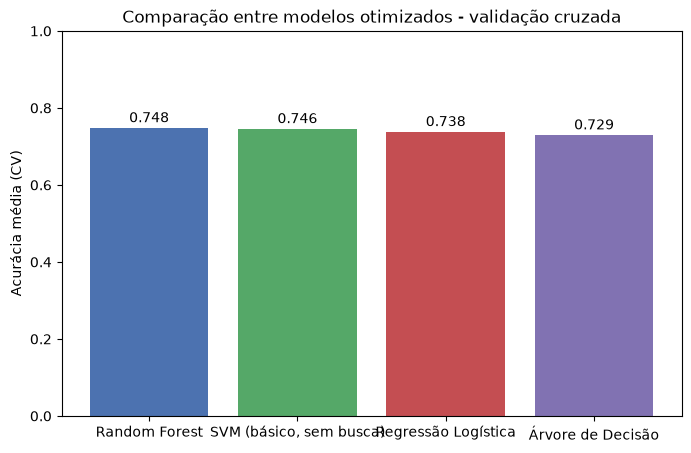

In [9]:
plot_comparacao_modelos(
    comparacao, coluna_valor="Acurácia média (CV)",
    titulo="Comparação entre modelos otimizados - validação cruzada",
)


## 8. Treino (CV) x validação: os quatro candidatos generalizam?

Até aqui só olhei a acurácia média da validação cruzada, dentro do treino -
não sei se essa acurácia se sustenta fora dela. Com as três buscas fechadas
mais o SVM básico (Achado 39), decidi abrir a base de validação já nesta
etapa, pra comparar treino/CV x validação nos quatro candidatos ao mesmo
tempo, não só no modelo final escolhido como eu tinha planejado nos Achados
34/38. Registro essa mudança de plano no `decisoes.md`.

(Sobre por que o split é 80/20 com validação cruzada, e não um 60/20/20
literal, ver Achado 42 em `reports/decisoes.md`.)

**Ponto de atenção que vale deixar bem explícito:** em nenhum momento desta
etapa a base de validação entrou em algum `.fit()` - nem do pré-processador,
nem do modelo, nem da busca de hiperparâmetro. Ela só aparece do lado direito
de um `.predict()`, depois que cada modelo já estava totalmente treinado só
com o treino. É a mesma lógica de simular a chegada de dado novo em produção:
o modelo nunca viu essas escolas antes de ser avaliado nelas.

Uso Precisão, Recall e F1-score separados por classe (Não/Sim), não só a
média da classe "Sim" que sai por padrão do scikit-learn - assim dá pra ver
se algum modelo troca acerto numa classe pela outra sem isso aparecer só na
acurácia. Pro treino/CV, uso `cross_val_predict` com o mesmo `cv` de cada
modelo.

In [10]:
from src.evaluation.metricas import obter_previsoes_cv, comparar_metricas_completas
from src.visualization.graficos import plot_matrizes_confusao, plot_arvore

modelos_finais = {
    "Árvore de Decisão": busca_arvore.best_estimator_,
    "Random Forest": busca_rf.best_estimator_,
    "Regressão Logística": busca_log.best_estimator_,
    "SVM (básico)": pipe_svm_basico,
}

cv_por_modelo = {
    "Árvore de Decisão": cv_padrao,
    "Random Forest": cv_padrao,
    "Regressão Logística": cv_padrao,
    "SVM (básico)": cv_svm,
}

t0 = time.time()
previsoes_treino_cv, y_treino_usado = obter_previsoes_cv(
    modelos_finais, X_treino, y_treino, cv_por_modelo,
)
print(f"Tempo (previsões via CV no treino): {time.time() - t0:.1f}s")

previsoes_validacao = {
    nome: modelo.predict(X_validacao) for nome, modelo in modelos_finais.items()
}

c:\Users\wesle\dev\ai-scientist-tech-challenge-3-modeling\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\wesle\dev\ai-scientist-tech-challenge-3-modeling\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
c:\Users\wesle\dev\ai-scientist-tech-challenge-3-modeling\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'pen

Tempo (previsões via CV no treino): 280.7s


In [11]:
previsoes_por_base = {
    "Treino (CV)": {nome: (y_treino_usado[nome], previsoes_treino_cv[nome]) for nome in modelos_finais},
    "Validação": {nome: (y_validacao, previsoes_validacao[nome]) for nome in modelos_finais},
}

tabela_metricas_completas = comparar_metricas_completas(previsoes_por_base)
tabela_metricas_completas

,Modelo,Base,Classe,Acurácia,Precisão,Recall,F1-score
0,Random Forest,Treino (CV),Não,0.747945,0.732073,0.698582,0.714935
1,Random Forest,Treino (CV),Sim,0.747945,0.760004,0.788735,0.774103
2,Random Forest,Validação,Não,0.748196,0.732402,0.698902,0.715260
3,Random Forest,Validação,Sim,0.748196,0.760200,0.788939,0.774303
4,Regressão Logística,Treino (CV),Não,0.737861,0.727581,0.672374,0.698889
5,Regressão Logística,Treino (CV),Sim,0.737861,0.745249,0.791975,0.767902
6,Regressão Logística,Validação,Não,0.736842,0.728780,0.666492,0.696246
7,Regressão Logística,Validação,Sim,0.736842,0.742534,0.794988,0.767866
8,SVM (básico),Treino (CV),Não,0.745579,0.731682,0.691131,0.710829
9,SVM (básico),Treino (CV),Sim,0.745579,0.755951,0.790571,0.772874


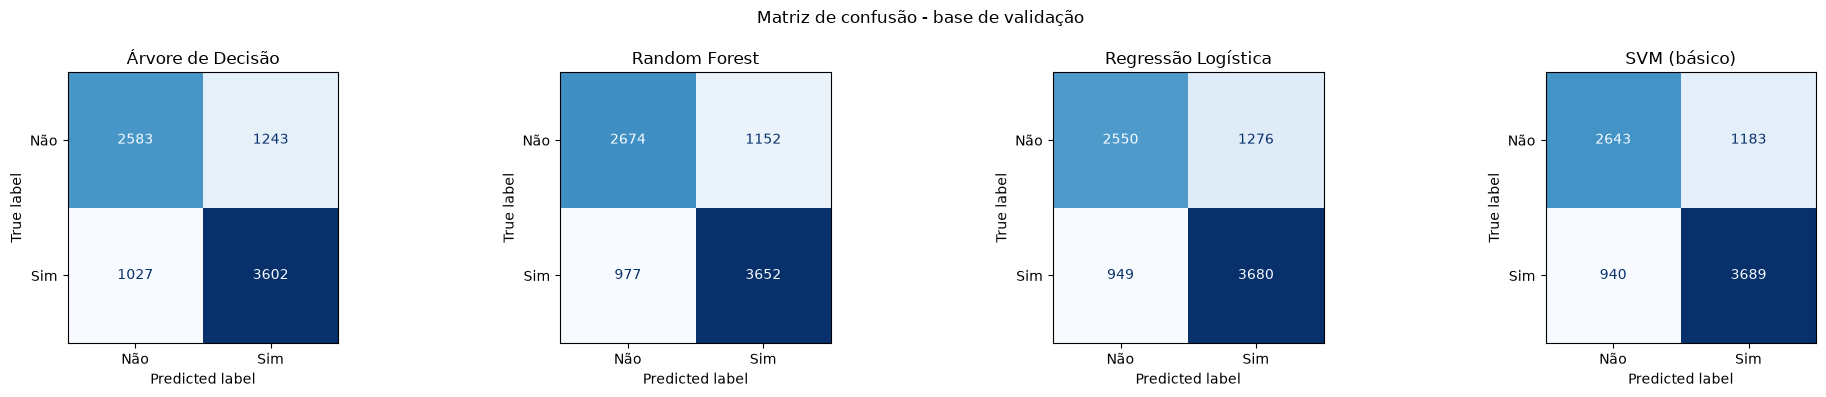

In [12]:
plot_matrizes_confusao(previsoes_validacao, y_validacao)

## 9. Interpretabilidade: o que cada modelo deixa eu enxergar

Gosto de Árvore de Decisão justamente por dar pra abrir o modelo e ver a regra
- é o oposto de caixa-preta. Random Forest perde o desenho único (são centenas
de árvores), mas ainda dá pra perguntar "quais features pesaram mais no
conjunto todo", via `feature_importances_`. Regressão Logística também é
interpretável, de um jeito diferente: cada coeficiente tem sinal (aumenta ou
diminui a chance da escola bater a meta) e magnitude (o quanto). SVM com kernel RBF (que entra aqui na versão básica, sem busca de
hiperparâmetro - Achado 39) é o mais opaco do grupo - a fronteira de decisão vive num espaço
transformado pelo kernel, sem uma tradução direta "essa feature pesa X" como
nos outros três; pra explicar previsão de SVM de verdade eu precisaria de uma
técnica pós-hoc tipo SHAP (com `KernelExplainer`, ainda mais caro
computacionalmente que o próprio treino).

Isso importa pra este projeto porque o público final não é só "o modelo mais
acurado" - é gente de política pública que vai querer entender *por que* uma
escola foi marcada como risco, pra saber em que investir. Um modelo 2-3 pontos
percentuais mais acurado mas impossível de explicar pode valer menos, na
prática, que um modelo um pouco pior mas auditável. Registro essa reflexão
aqui, mas ainda não decidi trocar acurácia por interpretabilidade - só deixo o
argumento explícito pra decidir com calma na escolha final.


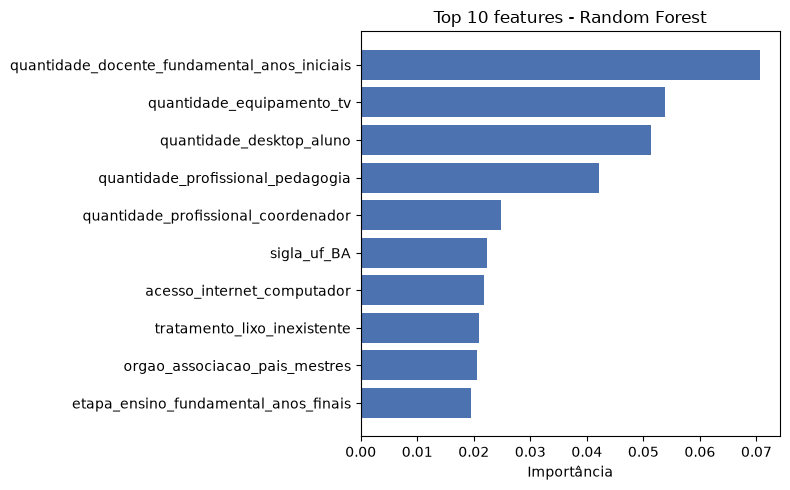

In [13]:
melhor_rf = busca_rf.best_estimator_.named_steps["clf"]
nomes_rf = [
    n.split("__", 1)[1] if "__" in n else n
    for n in busca_rf.best_estimator_.named_steps["prep"].get_feature_names_out()
]
importancias_rf = pd.Series(melhor_rf.feature_importances_, index=nomes_rf)
plot_importancia_features(importancias_rf, top_n=10, titulo="Top 10 features - Random Forest")


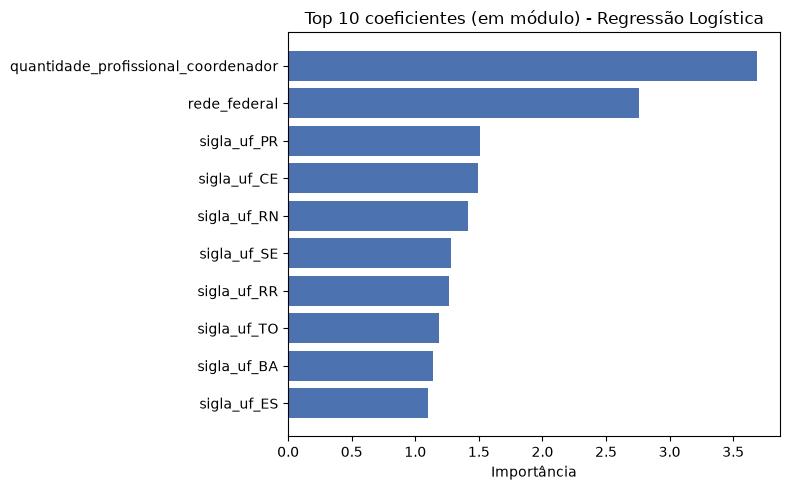

In [14]:
melhor_log = busca_log.best_estimator_.named_steps["clf"]
nomes_log = busca_log.best_estimator_.named_steps["prep"].get_feature_names_out()
nomes_log = [n.split("__", 1)[1] if "__" in n else n for n in nomes_log]
coeficientes = pd.Series(melhor_log.coef_[0], index=nomes_log)
plot_importancia_features(coeficientes.abs(), top_n=10, titulo="Top 10 coeficientes (em módulo) - Regressão Logística")


## 10. Árvore de Decisão otimizada: desenho e importância de feature

Seção dedicada só à árvore, já que é o modelo mais fácil de auditar visualmente
dos quatro - dá pra abrir e ver exatamente a regra que ela aprendeu, sem
precisar de nenhuma técnica de interpretabilidade pós-hoc.

O melhor hiperparâmetro encontrado (Achado 38) foi `max_depth=None` - ou seja,
sem limite de profundidade imposto na busca (só o `min_samples_leaf=50`
limitando de outro jeito, exigindo pelo menos 50 escolas por folha). Desenhar
essa árvore inteira ficaria ilegível, então uso `profundidade_exibicao` (um
parâmetro que criei em `plot_arvore` só pra isso) pra limitar quantos níveis
aparecem no desenho - isso corta só o desenho, não muda o modelo treinado nem
as previsões que ele faz.

In [ ]:
melhor_arvore = busca_arvore.best_estimator_.named_steps["clf"]
nomes_arvore = busca_arvore.best_estimator_.named_steps["prep"].get_feature_names_out()

plot_arvore(
    melhor_arvore, nomes_arvore,
    figsize=(26, 12), profundidade_exibicao=3,
)

In [ ]:
importancias_arvore = pd.Series(
    melhor_arvore.feature_importances_,
    index=[n.split("__", 1)[1] if "__" in n else n for n in nomes_arvore],
)
plot_importancia_features(importancias_arvore, top_n=10, titulo="Top 10 features - Árvore de Decisão otimizada")

## 11. Síntese e decisão final

Resultado da busca de hiperparâmetro, entre os três candidatos otimizados,
mais o SVM na versão básica (Achado 39):

- **Random Forest** vence entre os quatro (0,7479 de acurácia média em CV).
- **SVM (básico)** entra logo atrás, sem precisar de busca nenhuma (0,7456).
- **Regressão Logística** melhora um pouco com a regularização certa, mas
  fica atrás dos dois primeiros (0,7379).
- **Árvore de Decisão**, mesmo otimizada, é a mais fraca dos quatro em
  acurácia bruta (0,7294), mas segue sendo a mais fácil de auditar
  visualmente (Seção 10).

A comparação treino (CV) x validação da Seção 8 não mostrou sinal de
overfitting em nenhum dos três otimizados: a diferença entre treino/CV e
validação ficou pequena (menos de 0,3 ponto percentual) pra Random Forest,
Regressão Logística e Árvore de Decisão, inclusive a Árvore saiu um pouco
melhor na validação do que na própria validação cruzada, o que é normal
dentro da variação esperada, não um sinal de problema.

**✅ Decisão final: Árvore de Decisão.** Fechei nessa escolha por dois
motivos, nessa ordem de importância:

1. **Interpretabilidade.** É o único dos quatro candidatos que dá pra abrir e
   ler a regra de decisão diretamente (Seção 10), sem depender de nenhuma
   técnica de interpretabilidade pós-hoc. Isso importa porque o problema é de
   política pública (identificar escola em risco de não bater a meta do
   IDEB): quem for usar o modelo precisa conseguir explicar por que uma
   escola específica foi sinalizada, não só confiar num número de acurácia.
   Random Forest e SVM (RBF) são caixa-preta na prática; Regressão Logística
   dá coeficiente, mas não a mesma leitura direta de regra condicional que a
   árvore dá.
2. **Diferença de performance pequena.** A diferença entre a Árvore (0,7294)
   e o topo (Random Forest, 0,7479) é de 1,85 ponto percentual de acurácia
   média em CV. Testei também a Árvore com uma busca de hiperparâmetro bem
   mais pesada, em notebook separado (`11_otimizacao_avancada_arvore.ipynb`,
   Achado 43): mesmo com 400 combinações (contra 64 da busca daqui), escala
   log no `ccp_alpha` e um critério de seleção que penaliza gap treino-CV,
   o ganho de acurácia foi pequeno (0,7304 nessa busca contra 0,7294 aqui) e
   não generalizou melhor pra validação - a árvore da busca leve (aqui) teve
   acurácia de validação de 0,7315, contra 0,7224 da árvore da busca pesada,
   e AUC de 0,791 contra 0,785. Ou seja, a busca mais cara não trouxe ganho
   real: fico com a configuração mais simples (`min_samples_leaf=50`, sem
   limitar `max_depth`), que além de mais barata generalizou igual ou melhor.

Não vejo diferença de performance grande o suficiente entre os quatro
candidatos pra justificar abrir mão da interpretabilidade da Árvore - 1 a 2
pontos percentuais de acurácia não parecem decisivos pra esse problema,
enquanto conseguir explicar a decisão escola a escola parece um ganho real
pra quem for usar isso na prática.

## 12. Exploratório: reduzir o número de features ajuda os candidatos? (decisão pendente)

Isso ainda não é uma decisão fechada, é um teste de hipótese. A ideia parte de
uma pergunta que fiz sobre otimização: será que menos features (removendo
ruído/redundância que sobrou mesmo depois do funil do notebook 08) melhora os
modelos, principalmente os mais sensíveis à quantidade de dimensões (o SVM com
kernel RBF usa a distância entre pontos pra decidir a fronteira, e essa
distância fica mais "diluída" quanto mais dimensões existem - efeito conhecido
como maldição da dimensionalidade; a Árvore de Decisão também pode se
beneficiar de menos ruído, já que cada corte é escolhido olhando uma feature
de cada vez)?

O nome técnico correto pra isso é **seleção de features** (não confundir com
**redução de dimensionalidade** no sentido estrito - técnicas como PCA
projetam as colunas originais em eixos novos, compostos, sem apagar nenhuma
coluna original; aqui a ideia é remover colunas mesmo, mantendo as que sobram
com o significado original). Já fiz uma rodada de seleção de features no
notebook 08 (funil de nulos, baixa variância, correlação, multicolinearidade -
176 candidatas viraram 47). O que exploro aqui é uma segunda rodada, em cima
das 47 que já sobreviveram, usando a importância que a própria Random Forest
otimizada (Seção 4) já calculou.

A ferramenta certa do scikit-learn pra isso é `SelectFromModel`
(`sklearn.feature_selection`): recebe um modelo já treinado (ou treina um por
dentro) e mantém só as features com importância acima de um limiar. Existe
também `RFECV` (Recursive Feature Elimination com validação cruzada), que
testa remover features uma a uma e escolhe o número ideal sozinho - mais
rigoroso, mas caro de rodar direto com modelos como o SVM (cada rodada de
eliminação precisaria refitar o modelo várias vezes). Por isso, uso a Random
Forest (barata) só pra *ranquear* as features com `SelectFromModel`, e testo
os outros modelos com o subconjunto reduzido - não uso nenhum deles dentro do
processo de seleção em si.

**Ordem de teste:** testo primeiro na Árvore de Decisão, que hoje é a
candidata mais forte pra virar o modelo final (mais fácil de auditar
visualmente, Seção 10), e depois no SVM (a motivação original da pergunta).
Deixei a função de montagem do pipeline reduzido genérica, então dá pra
reaproveitar depois pra Random Forest e Regressão Logística também, se fizer
sentido depois de ver esses dois primeiros resultados.

**Plano:**
1. Pegar a importância de feature já calculada pela Random Forest otimizada.
2. Cortar num limiar (mantendo só as features acima da importância mediana)
   usando `SelectFromModel`.
3. Rodar a Árvore de Decisão otimizada só com esse subconjunto reduzido,
   comparando acurácia (CV) contra a Árvore com as 47 features inteiras
   (Seção 3).
4. Rodar o SVM básico (Seção 6) do mesmo jeito, comparando contra o SVM com
   todas as features.
5. Se algum dos dois vier melhor (ou igual, mas mais rápido) com o
   subconjunto reduzido, viraria um novo Achado formal em `decisoes.md`, e eu
   aplicaria o mesmo corte nos outros modelos pra comparar de novo. Se não
   vier melhor, registro o teste e sigo com as 47 features originais - de
   qualquer forma, o resultado vira um Achado.


In [ ]:
from sklearn.feature_selection import SelectFromModel

melhor_rf_para_selecao = busca_rf.best_estimator_.named_steps["clf"]

def construir_pipeline_reduzido(classificador, escalar_numericas):
    """
    Mesmo ColumnTransformer de sempre, com um SelectFromModel no meio usando
    como referência a Random Forest já otimizada (Seção 4) pra ranquear as
    features, cortando pela importância mediana (threshold="median").

    Uso prefit=False (não prefit=True): cross_val_score/GridSearchCV clonam
    o pipeline inteiro (sklearn.base.clone) antes de rodar cada fold, e
    clonar apaga o estado treinado de qualquer estimator aninhado, inclusive
    a Random Forest já fitada dentro do SelectFromModel. Com prefit=True isso
    quebra com NotFittedError assim que a validação cruzada tenta rodar. Com
    prefit=False, o próprio SelectFromModel clona e refita uma cópia nova da
    Random Forest (com os mesmos hiperparâmetros de melhor_rf_para_selecao)
    só com o treino de cada fold, o que também é mais correto do ponto de
    vista de vazamento: evita usar a importância de uma Random Forest que viu
    o treino inteiro (inclusive a parte que vira "teste" daquele fold) pra
    selecionar feature de outro modelo.
    """
    return Pipeline([
        ("prep", construir_preprocessador(escalar_numericas=escalar_numericas)),
        ("selecao", SelectFromModel(melhor_rf_para_selecao, threshold="median", prefit=False)),
        ("clf", classificador),
    ])

n_features_antes = len(busca_rf.best_estimator_.named_steps["prep"].get_feature_names_out())
print(f"Features antes do corte (depois do One-Hot): {n_features_antes}")


In [ ]:
# 12.1 - Árvore de Decisão (candidata mais forte no momento) com o subconjunto reduzido
parametros_arvore_reduzida = {
    k.replace("clf__", ""): v for k, v in busca_arvore.best_params_.items()
}
pipe_arvore_reduzida = construir_pipeline_reduzido(
    DecisionTreeClassifier(random_state=42, **parametros_arvore_reduzida),
    escalar_numericas=False,
)

t0 = time.time()
acuracia_arvore_reduzida = cross_val_score(
    pipe_arvore_reduzida, X_treino, y_treino, cv=cv_padrao, scoring="accuracy", n_jobs=-1,
).mean()
tempo_arvore_reduzida = time.time() - t0

print(f"Árvore com features reduzidas - Acurácia média (CV): {acuracia_arvore_reduzida:.4f}, tempo: {tempo_arvore_reduzida:.1f}s")
print(f"Árvore otimizada (Seção 3, todas as features) - Acurácia média (CV): {resultados_cv['Árvore de Decisão']:.4f}")


In [ ]:
# 12.2 - SVM (motivação original da pergunta) com o subconjunto reduzido
pipe_svm_reduzido = construir_pipeline_reduzido(SVC(kernel="rbf"), escalar_numericas=True)

t0 = time.time()
acuracia_svm_reduzido = cross_val_score(
    pipe_svm_reduzido, X_treino, y_treino, cv=cv_svm, scoring="accuracy", n_jobs=-1,
).mean()
tempo_svm_reduzido = time.time() - t0

print(f"SVM com features reduzidas - Acurácia média (CV): {acuracia_svm_reduzido:.4f}, tempo: {tempo_svm_reduzido:.1f}s")
print(f"SVM básico (Seção 6, todas as features) - Acurácia média (CV): {resultados_cv['SVM (básico, sem busca)']:.4f}")

# 🔶 Decisão pendente: se a Árvore e/ou o SVM vierem melhores (ou só um pouco
# piores, mas com fit bem mais rápido) com o subconjunto reduzido, vale
# considerar adotar o corte de features nos outros modelos também - registrar
# em decisoes.md se for esse o caminho.
